# Alfido Tech — Superstore Sales Performance Analysis

**Dataset:** `superstore_final_dataset.csv` (9,800 order line items, 2015–2018)
**Objective:** Clean the sales/order data, compute KPIs, analyze performance across regions/categories/time, identify best & worst products and seasonality, and produce tactical recommendations.

---

## 1. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11,
                      'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv("superstore_final_dataset (1).csv", encoding="latin1")
df.columns = [c.strip() for c in df.columns]
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


## 2. Data Types & Missing Values

Basic inspection of column types and completeness before cleaning.

In [2]:
dtypes_tbl = df.dtypes.astype(str).rename("dtype").to_frame()
missing_tbl = df.isnull().sum().rename("missing_values").to_frame()
missing_tbl["missing_pct"] = (missing_tbl["missing_values"] / len(df) * 100).round(2)

report = dtypes_tbl.join(missing_tbl)
report

,dtype,missing_values,missing_pct
Row_ID,int64,0,0.00
Order_ID,str,0,0.00
Order_Date,str,0,0.00
Ship_Date,str,0,0.00
Ship_Mode,str,0,0.00
Customer_ID,str,0,0.00
Customer_Name,str,0,0.00
Segment,str,0,0.00
Country,str,0,0.00
City,str,0,0.00


**Observation:** Only `Postal_Code` has missing values (11 rows, ~0.1%) — negligible and not required for regional analysis (we use `Region`/`State` instead). No other columns have missing data. There are no duplicate rows.

In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing Postal_Code rows:", df['Postal_Code'].isnull().sum())

Duplicate rows: 0
Missing Postal_Code rows: 11


## 3. Data Cleaning & Preparation

- Parse `Order_Date` / `Ship_Date` (format confirmed as `DD/MM/YYYY` — verified by checking for day values > 12, which rules out `MM/DD/YYYY`).
- Fill missing `Postal_Code` with -1 (unknown) and cast to integer.
- Derive `Order_Year`, `Order_Month`, `Order_YearMonth`, and `Ship_Lead_Days` (fulfillment speed) for trend/seasonality analysis.

In [4]:
df = df.drop_duplicates()

df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y', errors='coerce')
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  format='%d/%m/%Y', errors='coerce')

df['Postal_Code'] = df['Postal_Code'].fillna(-1).astype(int)

df['Order_Year']      = df['Order_Date'].dt.year
df['Order_Month']     = df['Order_Date'].dt.month
df['Order_MonthName'] = df['Order_Date'].dt.strftime('%b')
df['Order_YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
df['Ship_Lead_Days']  = (df['Ship_Date'] - df['Order_Date']).dt.days

print("Unparsed Order_Date rows:", df['Order_Date'].isna().sum())
print("Date range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())
df[['Order_Date','Ship_Date','Order_YearMonth','Ship_Lead_Days']].head()

Unparsed Order_Date rows: 0
Date range: 2015-01-03 to 2018-12-30


,Order_Date,Ship_Date,Order_YearMonth,Ship_Lead_Days
0,2017-11-08,2017-11-11,2017-11,3
1,2017-11-08,2017-11-11,2017-11,3
2,2017-06-12,2017-06-16,2017-06,4
3,2016-10-11,2016-10-18,2016-10,7
4,2016-10-11,2016-10-18,2016-10,7


## 4. Summary Statistics

Mean, median, mode for numeric columns; mode & cardinality for key categorical columns.

In [5]:
numeric_summary = df[['Sales','Ship_Lead_Days']].agg(
    ['mean','median', lambda x: x.mode().iloc[0], 'std','min','max']
).T
numeric_summary.columns = ['mean','median','mode','std','min','max']
numeric_summary.round(2)

,mean,median,mode,std,min,max
Sales,230.77,54.49,12.96,626.65,0.44,22638.48
Ship_Lead_Days,3.96,4.00,4.00,1.75,0.00,7.00


In [6]:
cat_cols = ['Ship_Mode','Segment','Region','Category','Sub_Category']
cat_summary = pd.DataFrame({
    'unique_values': [df[c].nunique() for c in cat_cols],
    'mode':          [df[c].mode().iloc[0] for c in cat_cols],
    'mode_freq':     [df[c].value_counts().iloc[0] for c in cat_cols],
}, index=cat_cols)
cat_summary

,unique_values,mode,mode_freq
Ship_Mode,4,Standard Class,5859
Segment,3,Consumer,5101
Region,4,West,3140
Category,3,Office Supplies,5909
Sub_Category,17,Binders,1492


**Key takeaways:**
- Average order-line value is **\$230.77**, but the **median is only \$54.49** — a small number of high-value Technology items (e.g. copiers, printers) pull the mean far above the typical transaction.
- **Standard Class** is the dominant shipping mode (60% of lines); average fulfillment time is **~4 days**.
- **Office Supplies** has by far the most line items (5,909) despite not being the top revenue category — high order frequency, low unit value.

## 5. Basic Visualizations

Three foundational charts summarizing the most important columns: a **bar chart** (revenue by category), a **line chart** (monthly revenue trend), and a **histogram** (distribution of order-line sales values).

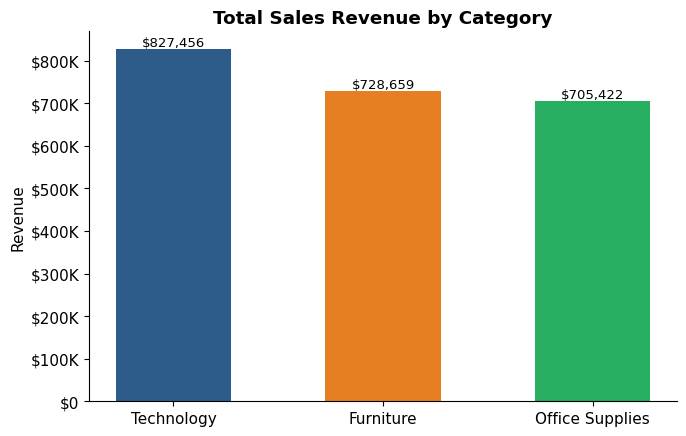

In [7]:
def money_fmt(x, pos):
    return f"${x/1000:,.0f}K" if x >= 1000 else f"${x:,.0f}"

rev_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(rev_category.index, rev_category.values, color=['#2E5C8A','#E67E22','#27AE60'], width=0.55)
ax.set_title("Total Sales Revenue by Category", fontweight='bold')
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+8000, f"${b.get_height():,.0f}", ha='center', fontsize=9.5)
plt.tight_layout()
plt.show()

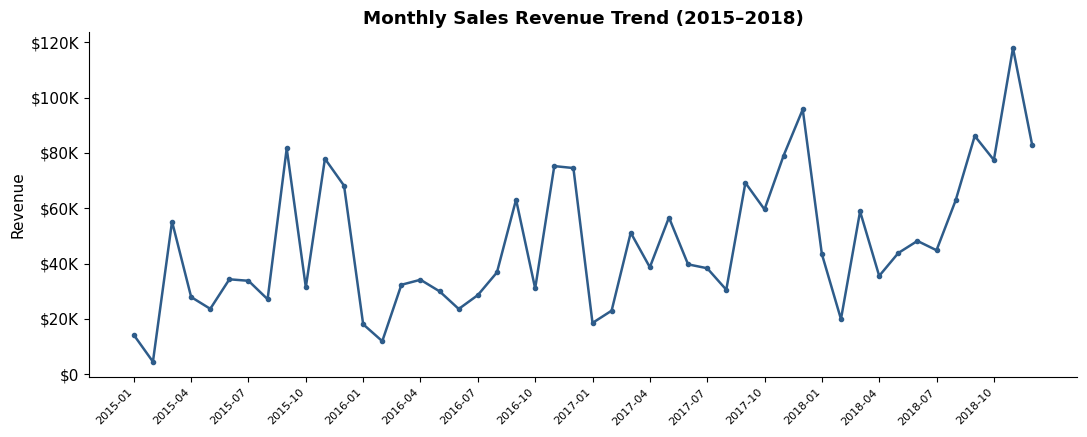

In [8]:
monthly = df.groupby('Order_YearMonth')['Sales'].sum()

fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(monthly.index, monthly.values, color='#2E5C8A', linewidth=1.8, marker='o', markersize=3)
ax.set_title("Monthly Sales Revenue Trend (2015\u20132018)", fontweight='bold')
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ticks = monthly.index[::3]
ax.set_xticks(ticks); ax.set_xticklabels(ticks, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

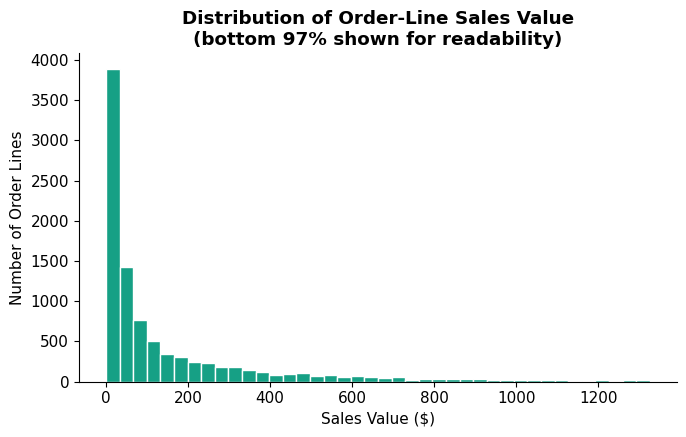

In [9]:
data = df[df['Sales'] < df['Sales'].quantile(0.97)]['Sales']  # trim top 3% for readability

fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(data, bins=40, color='#16A085', edgecolor='white')
ax.set_title("Distribution of Order-Line Sales Value\n(bottom 97% shown for readability)", fontweight='bold')
ax.set_xlabel("Sales Value ($)")
ax.set_ylabel("Number of Order Lines")
plt.tight_layout()
plt.show()

## 6. Key Performance Indicators (KPIs)

**Note on scope:** this dataset contains `Sales` (revenue) only — there are **no `Profit`, `Discount`, or `Quantity` columns**, so profit margin and unit-based conversion metrics cannot be computed directly from the data as given. Where a metric isn't available, that limitation is stated explicitly rather than estimated.

In [10]:
total_revenue   = df['Sales'].sum()
n_orders        = df['Order_ID'].nunique()
n_line_items    = len(df)
aov             = total_revenue / n_orders
avg_line_value  = df['Sales'].mean()
avg_ship_lead   = df['Ship_Lead_Days'].mean()
date_min, date_max = df['Order_Date'].min(), df['Order_Date'].max()

kpis = pd.Series({
    "Total Revenue": f"${total_revenue:,.2f}",
    "Distinct Orders": f"{n_orders:,}",
    "Order Line Items": f"{n_line_items:,}",
    "Average Order Value (AOV)": f"${aov:,.2f}",
    "Average Line-Item Value": f"${avg_line_value:,.2f}",
    "Avg Shipping Lead Time (days)": f"{avg_ship_lead:.1f}",
    "Date Range": f"{date_min.date()} to {date_max.date()}",
    "Profit Margin": "N/A — no Profit/Cost column in source data",
    "Conversion Rate": "N/A — no visits/leads column in source data",
}, name="Value")
kpis.to_frame()

,Value
Total Revenue,"$2,261,536.78"
Distinct Orders,"4,922"
Order Line Items,"9,800"
Average Order Value (AOV),$459.48
Average Line-Item Value,$230.77
Avg Shipping Lead Time (days),4.0
Date Range,2015-01-03 to 2018-12-30
Profit Margin,N/A — no Profit/Cost column in source data
Conversion Rate,N/A — no visits/leads column in source data


## 7. Regional & Category Performance

In [11]:
rev_region    = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
orders_region = df.groupby('Region')['Order_ID'].nunique()
aov_region    = (rev_region / orders_region).reindex(rev_region.index)

perf_region = pd.DataFrame({
    'Total Revenue': rev_region,
    'Orders': orders_region.reindex(rev_region.index),
    'AOV': aov_region.round(2)
})
perf_region

,Total Revenue,Orders,AOV
Region,,,
West,710219.6845,1587,447.52
East,669518.7260,1369,489.06
Central,492646.9132,1156,426.17
South,389151.4590,810,480.43


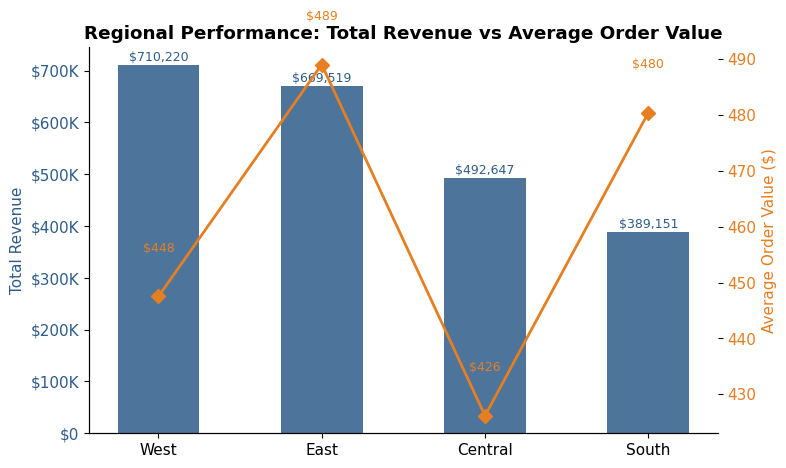

In [12]:
fig, ax1 = plt.subplots(figsize=(8,4.8))
bars = ax1.bar(rev_region.index, rev_region.values, color='#2E5C8A', alpha=0.85, width=0.5)
ax1.set_ylabel("Total Revenue", color='#2E5C8A')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax1.tick_params(axis='y', labelcolor='#2E5C8A')
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+8000, f"${b.get_height():,.0f}", ha='center', fontsize=9, color='#2E5C8A')

ax2 = ax1.twinx()
ax2.plot(rev_region.index, aov_region.values, color='#E67E22', marker='D', linewidth=2, markersize=7)
ax2.set_ylabel("Average Order Value ($)", color='#E67E22')
ax2.tick_params(axis='y', labelcolor='#E67E22')
for i,(x,v) in enumerate(zip(rev_region.index, aov_region.values)):
    ax2.text(i, v+8, f"${v:,.0f}", ha='center', fontsize=9, color='#E67E22')

ax1.set_title("Regional Performance: Total Revenue vs Average Order Value", fontweight='bold')
plt.tight_layout()
plt.show()

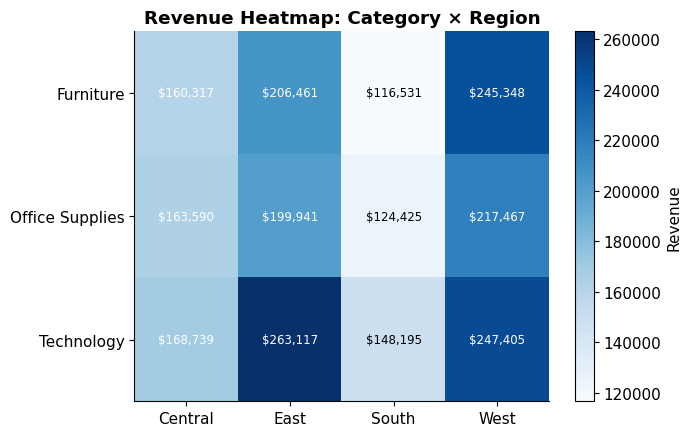

In [13]:
pivot = df.pivot_table(index='Category', columns='Region', values='Sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(7,4.5))
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        color = 'white' if val > pivot.values.max()*0.6 else 'black'
        ax.text(j, i, f"${val:,.0f}", ha='center', va='center', fontsize=8.5, color=color)
ax.set_title("Revenue Heatmap: Category \u00d7 Region", fontweight='bold')
plt.colorbar(im, ax=ax, label='Revenue')
plt.tight_layout()
plt.show()

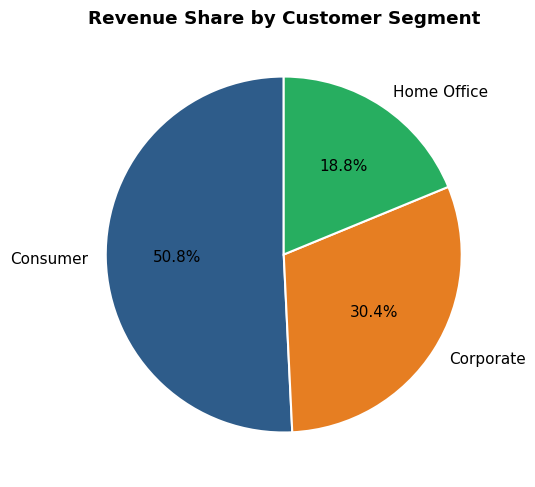

In [14]:
seg_rev = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5.5,5.5))
ax.pie(seg_rev.values, labels=seg_rev.index, autopct='%1.1f%%',
       colors=['#2E5C8A','#E67E22','#27AE60'], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title("Revenue Share by Customer Segment", fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Best & Worst Performing Products

In [15]:
prod_rev = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False)
top10 = prod_rev.head(10)
bottom10 = prod_rev.tail(10)

print("=== TOP 10 PRODUCTS BY REVENUE ===")
print(top10.round(2))
print()
print("=== BOTTOM 10 PRODUCTS BY REVENUE ===")
print(bottom10.round(2))

=== TOP 10 PRODUCTS BY REVENUE ===
Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.69
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.90
GBC DocuBind P400 Electric Binding System                                      17965.07
High Speed Automatic Electric Letter Opener                                    17030.31
Name: Sales, dtype: float64

=== BOTTOM 10 PRODUCTS BY REVENUE ===
Produ

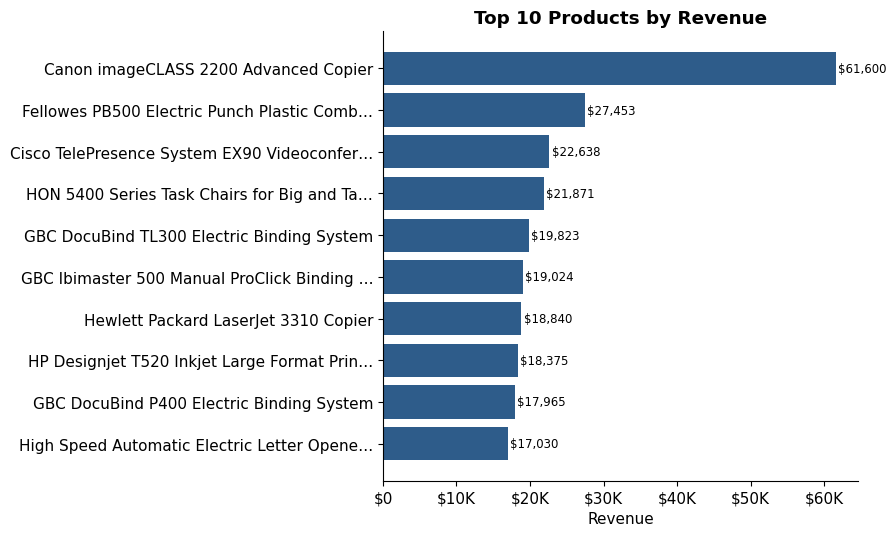

In [16]:
labels = [(p[:42] + '\u2026') if len(p) > 42 else p for p in top10.index]

fig, ax = plt.subplots(figsize=(9,5.5))
bars = ax.barh(labels[::-1], top10.values[::-1], color='#2E5C8A')
ax.set_title("Top 10 Products by Revenue", fontweight='bold')
ax.set_xlabel("Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
for b in bars:
    ax.text(b.get_width()+300, b.get_y()+b.get_height()/2, f"${b.get_width():,.0f}", va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

## 9. Seasonality Analysis

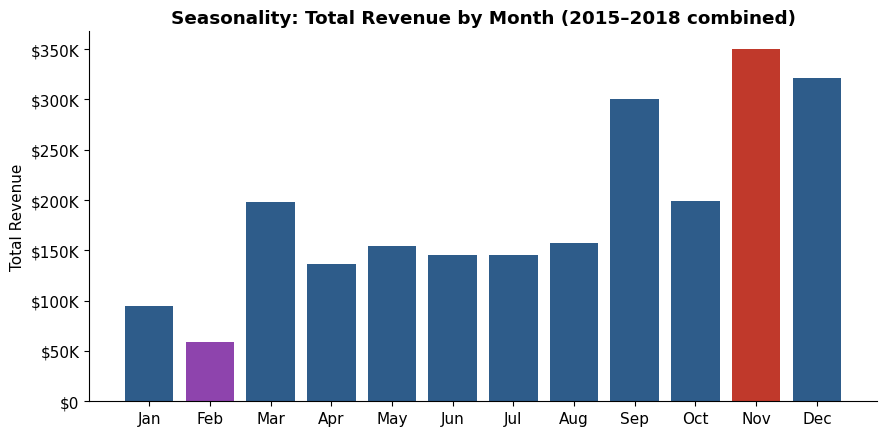

Strongest month: Nov  ($350,162 total across all years)
Weakest month:   Feb  ($59,371 total across all years)


In [17]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
moy = df.groupby('Order_Month')['Sales'].sum().reindex(range(1,13), fill_value=0)

colors = ['#C0392B' if v == moy.max() else ('#8E44AD' if v == moy.min() else '#2E5C8A') for v in moy.values]

fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(month_names, moy.values, color=colors)
ax.set_title("Seasonality: Total Revenue by Month (2015\u20132018 combined)", fontweight='bold')
ax.set_ylabel("Total Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()

best_m, worst_m = moy.idxmax(), moy.idxmin()
print(f"Strongest month: {month_names[best_m-1]}  (${moy.max():,.0f} total across all years)")
print(f"Weakest month:   {month_names[worst_m-1]}  (${moy.min():,.0f} total across all years)")

**Pattern:** Revenue builds steadily from spring, dips slightly in mid-summer, then climbs sharply into **September–December**, peaking in **November** (Black Friday / Cyber Monday / year-end business purchasing) — a **~6x** difference between the strongest and weakest month. **February** is consistently the weakest month, likely a post-holiday/budget-reset lull.

## 10. Executive Summary & Actionable Insights

**Alfido Tech — Sales Performance Summary (2015–2018)**

Over the four-year period, the business generated **\$2,261,536.78** in total revenue across **4,922 orders** (9,800 order lines), for an average order value of **\$459.48**. **Technology** is the top revenue category (\$827K) despite having the fewest line items, driven by high-ticket products like copiers and networking equipment. The **West** and **East** regions together generate ~61% of revenue, while the **South** region lags all others in both total revenue and order volume. Sales are highly seasonal, peaking in **November** and troughing in **February**, a ~6x swing that should drive inventory and staffing planning.

### 3 Actionable Insights

1. **Double down on Technology in underperforming regions.** Technology drives the highest revenue per line item but its regional distribution is uneven — the South region under-indexes on Technology sales relative to West/East. A targeted push (bundling, promotions, sales-rep incentives) on Technology in the South could close a meaningful share of the regional gap.

2. **Plan inventory and marketing around the Sep–Nov surge.** With November revenue ~6x February's, Alfido Tech should pre-build stock and launch promotional campaigns starting **August/September** to be ready for the Sep–Nov demand ramp, and use the Jan–Feb trough for clearance/liquidation promotions on slow-moving stock instead of standard pricing.

3. **Protect and grow the low-frequency, high-value product tail.** The top 10 products (copiers, binding machines, big-ticket furniture) generate a disproportionate share of revenue relative to their order count. These should get premium placement, dedicated upsell/cross-sell paths (e.g. service contracts, accessories), and stock-out prevention, since losing one sale here costs far more than losing a \$10 office-supplies line item.

### 5 Tactical Improvements for Alfido Tech's Sales & Offerings

1. **Regional rebalancing:** Launch a dedicated South-region campaign (local promotions, sales incentives, or a regional distribution partner) to close the ~45% revenue gap versus the West.
2. **Seasonal inventory & staffing plan:** Build a demand-driven restocking calendar with safety stock increases starting August ahead of the Sep–Nov peak, and reduce/discount excess stock in Jan–Feb.
3. **Bundle high-margin Technology with high-frequency Office Supplies:** e.g., a printer + paper + toner bundle — to lift average order value across both categories.
4. **Introduce a loyalty/repeat-purchase program for the Consumer segment** (the largest segment by revenue share) to convert one-time buyers into repeat customers and lift order frequency.
5. **Instrument true conversion & profitability tracking:** Add `Quantity`, `Discount`, and `Cost/Profit` fields to the sales data pipeline going forward — without them, true profit margin and funnel conversion rate cannot be measured, which limits how precisely marketing spend and discounting can be optimized.

---
*Analysis based on `superstore_final_dataset.csv`, 9,800 order line items, Jan 2015–Dec 2018. Profit, discount, and quantity metrics were not available in the source data and are flagged above as a recommended data-collection improvement.*